# Data Set and Pre-Processing

In [1]:
%pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub
#this is the UNSW_NB15 dataset which is more modern
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Owner\.cache\kagglehub\datasets\mrwellsdavid\unsw-nb15\versions\1


In [3]:
#inspect files
import os
os.listdir(path)
#we see all of the fils that we could've downloaded on kaggle

['NUSW-NB15_features.csv',
 'UNSW-NB15_1.csv',
 'UNSW-NB15_2.csv',
 'UNSW-NB15_3.csv',
 'UNSW-NB15_4.csv',
 'UNSW-NB15_LIST_EVENTS.csv',
 'UNSW_NB15_testing-set.csv',
 'UNSW_NB15_training-set.csv']

In [4]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#but we really only want the training and testing set
import pandas as pd
train_df = pd.read_csv(os.path.join(path, "UNSW_NB15_training-set.csv"))
test_df = pd.read_csv(os.path.join(path, "UNSW_NB15_testing-set.csv"))

#for OUR project we want to combine both of these because we are doing UNSUPERVISED learning
#NOT traditional train / test splits

df_og = pd.concat([train_df, test_df], axis = 0)

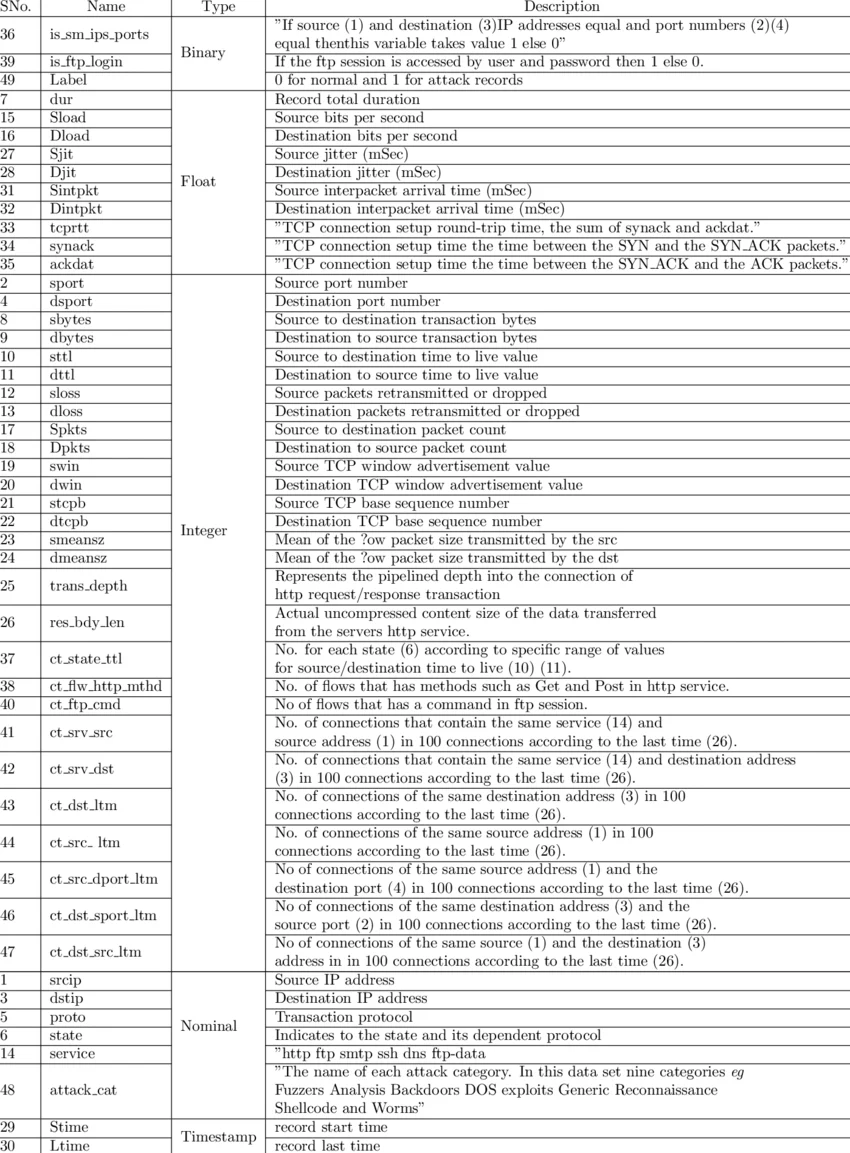

In [6]:
from IPython.display import Image
Image('C:\\Users\\Owner\\Documents\\aiProject\\image.png')

#THIS IS ALL OF THE COLUMNS, THEIR TYPE, AND A DESCRIPTION

In [7]:
print(df_og['label'].value_counts())
print(df_og['attack_cat'].value_counts())

#this is the names of the types of attacks, and I believe the number of them that occur in the dataset.

label
1    164673
0     93000
Name: count, dtype: int64
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64


There are columns of data that we do not need. NOTE that some of  the data was preprocessed prior to my downloading of the dataset. There were 4 removed columns of data.

BUT, we are attempting an "unsupervised" IDS model. In this way we can have a better model that

  1.) eliminates labelling costs

  2.) can better detect "zero-day attacks" which are attacks on flaws that were unknown to the model because they were not labelled as attacks in the training set.

  With an unsupervised model we can better determine abnormal behavior and flag it... ideally

The columns of data that we do not need are ID and label

In [8]:
#we want to see what column numbers correlate to the columns that we are wanting to drop
columns = df_og.columns
i=0
for column in columns:
  print(f"column number {i}: is {column}" )
  i+=1


column number 0: is id
column number 1: is dur
column number 2: is proto
column number 3: is service
column number 4: is state
column number 5: is spkts
column number 6: is dpkts
column number 7: is sbytes
column number 8: is dbytes
column number 9: is rate
column number 10: is sttl
column number 11: is dttl
column number 12: is sload
column number 13: is dload
column number 14: is sloss
column number 15: is dloss
column number 16: is sinpkt
column number 17: is dinpkt
column number 18: is sjit
column number 19: is djit
column number 20: is swin
column number 21: is stcpb
column number 22: is dtcpb
column number 23: is dwin
column number 24: is tcprtt
column number 25: is synack
column number 26: is ackdat
column number 27: is smean
column number 28: is dmean
column number 29: is trans_depth
column number 30: is response_body_len
column number 31: is ct_srv_src
column number 32: is ct_state_ttl
column number 33: is ct_dst_ltm
column number 34: is ct_src_dport_ltm
column number 35: is c

so we know that column's 0, 43, and 44 are the ID, attack_cat, and label, respectively. So we can drop these for our new dataset.

In [9]:
#df.drop removes columns that we do not need
df_new = df_og.drop(df_og.columns[[0, 43,44]], axis=1, inplace=False)
print(df_new)

             dur proto service state  spkts  dpkts  sbytes  dbytes  \
0       0.000011   udp       -   INT      2      0     496       0   
1       0.000008   udp       -   INT      2      0    1762       0   
2       0.000005   udp       -   INT      2      0    1068       0   
3       0.000006   udp       -   INT      2      0     900       0   
4       0.000010   udp       -   INT      2      0    2126       0   
...          ...   ...     ...   ...    ...    ...     ...     ...   
175336  0.000009   udp     dns   INT      2      0     114       0   
175337  0.505762   tcp       -   FIN     10      8     620     354   
175338  0.000009   udp     dns   INT      2      0     114       0   
175339  0.000009   udp     dns   INT      2      0     114       0   
175340  0.000009   udp     dns   INT      2      0     114       0   

                 rate  sttl  ...  ct_dst_ltm  ct_src_dport_ltm  \
0        90909.090200   254  ...           1                 1   
1       125000.000300   254

In [10]:
#we can now check to see that we no longer have an ID, attack cat, or a Label column. df.shape tells us we have two less columns than before
columns = df_new.columns
i=0
for column in columns:
  print(f"column number {i}: is {column}" )
  i+=1

column number 0: is dur
column number 1: is proto
column number 2: is service
column number 3: is state
column number 4: is spkts
column number 5: is dpkts
column number 6: is sbytes
column number 7: is dbytes
column number 8: is rate
column number 9: is sttl
column number 10: is dttl
column number 11: is sload
column number 12: is dload
column number 13: is sloss
column number 14: is dloss
column number 15: is sinpkt
column number 16: is dinpkt
column number 17: is sjit
column number 18: is djit
column number 19: is swin
column number 20: is stcpb
column number 21: is dtcpb
column number 22: is dwin
column number 23: is tcprtt
column number 24: is synack
column number 25: is ackdat
column number 26: is smean
column number 27: is dmean
column number 28: is trans_depth
column number 29: is response_body_len
column number 30: is ct_srv_src
column number 31: is ct_state_ttl
column number 32: is ct_dst_ltm
column number 33: is ct_src_dport_ltm
column number 34: is ct_dst_sport_ltm
column n

Now that we have handled dropping some columns, we have the issue of having some categorical columns as well. Proto, Service, and State, columns 1,2,3 respectively

Since we are doing a k-means implementation, these categorical values will not work. We could try "One-Hot Encoding" but this method will drastically increase our dimensionality. This is a problem because it ruins the spatial patterns and makes clustering difficult.

There exists an alternative, called k-prototype, which combine k-means, and k-modes methods in order to handle datasets that have both numerical and categorical values. This method used Euclidean distance for continuous data and matching dissimilarity for categorical data.

Since we are using a clustering-based unsupervised IDS, we need to be able to handle distance from a baseline considering both numerical and categorical features.

# Feature Values

**Basic Connection Features**  
- **dur** → Duration of the connection (how long the session lasts)  
- **proto** → Network protocol used (e.g., TCP, UDP)  
- **service** → Application-level service (e.g., HTTP, FTP, or “-” if unknown)  
- **state** → Connection state (status of the session, e.g., established, interrupted)  
----------------------------------------------------------

**Packet Counts & Volume**  
- **spkts** → Number of packets sent from source → destination  
- **dpkts** → Number of packets sent from destination → source  
- **sbytes** → Bytes sent from source → destination  
- **dbytes** → Bytes sent from destination → source  
----------------------------------------------------------

**Rate & TTL**  
- **rate** → Transmission rate (packets or bytes per second)  
- **sttl** → Source Time-To-Live (TTL value of packets sent)  
- **dttl** → Destination TTL (TTL of response packets)  
------------------------------------------------------------

**Load (Traffic Intensity)**  
- **sload** → Source data rate (bits per second sent)  
- **dload** → Destination data rate (bits per second received)  
--------------------------------------------------------------

**Packet Loss**  
- **sloss** → Number of packets lost from source  
- **dloss** → Number of packets lost from destination  
------------------------------------------------------------------

**Timing Between Packets**  
- **sinpkt** → Time between packets sent from source  
- **dinpkt** → Time between packets sent from destination  
-------------------------------------------------------------------------

**Jitter (Variation in Timing)**  
- **sjit** → Jitter in source packets (variation in send timing)  
- **djit** → Jitter in destination packets  
---------------------------------------------------------------

**TCP Window / Buffer Info**  
- **swin** → Source TCP window size  
- **stcpb** → Source TCP base sequence number  
- **dtcpb** → Destination TCP base sequence number  
- **dwin** → Destination TCP window size  
----------------------------------------------------------------

**TCP Timing Metrics**  
- **tcprtt** → TCP round-trip time (latency)  
- **synack** → Time between SYN and SYN-ACK  
- **ackdat** → Time between ACK and data transmission  
----------------------------------------------------------------------

**Packet Size Statistics**  
- **smean** → Mean packet size from source  
- **dmean** → Mean packet size from destination  
---------------------------------------------------------------------

**Application Layer Features**  
- **trans_depth** → Depth of HTTP transaction (number of request/response steps)  
- **response_body_len** → Size of HTTP response body  
---------------------------------------------------------------------------

**Connection Count Features**  
- **ct_srv_src** → Number of connections to same service from source  
- **ct_state_ttl** → Count of connections with same state and TTL  
- **ct_dst_ltm** → Connections to same destination over time  
- **ct_src_dport_ltm** → Connections from source to same destination port over time  
- **ct_dst_sport_ltm** → Connections to destination from same source port  
- **ct_dst_src_ltm** → Connections between same source-destination pair  
-------------------------------------------------------------

**Protocol-Specific Indicators**  
- **is_ftp_login** → Whether FTP login was attempted (1 = yes, 0 = no)  
- **ct_ftp_cmd** → Number of FTP commands used  
- **ct_flw_http_mthd** → Number of HTTP methods (GET, POST, etc.) used  
--------------------------------------------------------------------

**More Connection Counts**  
- **ct_src_ltm** → Connections from same source over time  
- **ct_srv_dst** → Connections to same service and destination  
---------------------------------------------------------------------

**Special Condition Feature**  
- **is_sm_ips_ports** → Whether source and destination IP/port are the same (can indicate unusual or suspicious behavior)


# K-Prototypes Model

In [11]:
#we will be using the KModes library "off-the-shelf" version of Kprototype for now

%pip install kmodes

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import numpy
import kmodes
from kmodes.kprototypes import KPrototypes

#selects specific columns from our df_new and converts their data types to string
df_new.iloc[:, [1,2,3]] = df_new.iloc[:, [1,2,3]].astype(str)
#convert our df into numpy array
data_np = df_new.to_numpy()

#initialize our model using 4 clusters (random for now), using the Huang Variation, and n_init to 1 (which is how many times the algorithm will re run with different initial prototypes)
km = KPrototypes(n_clusters=5, init='Huang', n_init=1, verbose=1)

clusters = km.fit_predict(data_np, categorical=[1,2,3])

# Print the cluster centroids
print(km.cluster_centroids_)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 61090, ncost: 1.1186857121300576e+23
Run: 1, iteration: 2/100, moves: 19156, ncost: 9.69111801215222e+22
Run: 1, iteration: 3/100, moves: 9743, ncost: 9.393583727655982e+22
Run: 1, iteration: 4/100, moves: 4977, ncost: 9.32735256894564e+22
Run: 1, iteration: 5/100, moves: 2172, ncost: 9.314163720986272e+22
Run: 1, iteration: 6/100, moves: 1217, ncost: 9.30991799707888e+22
Run: 1, iteration: 7/100, moves: 720, ncost: 9.308164384256693e+22
Run: 1, iteration: 8/100, moves: 534, ncost: 9.306915084544483e+22
Run: 1, iteration: 9/100, moves: 463, ncost: 9.30583956499022e+22
Run: 1, iteration: 10/100, moves: 403, ncost: 9.305176420934826e+22
Run: 1, iteration: 11/100, moves: 236, ncost: 9.304977239304078e+22
Run: 1, iteration: 12/100, moves: 109, ncost: 9.304922818140886e+22
Run: 1, iteration: 13/100, moves: 73, ncost: 9.30489901654364e+22
Run: 1, iteration: 14/100, moves: 51, ncos

# How to analyze an outputted cluster

```
[['1.124618505561206' '7.205922196010018' '4.67776169802219'
  '2479.375532779573' '3633.7761631941003' '154809.83611611451'
  '211.34869720939145' '19.301607755288146' '119935511.2779037'
  '203383.78165217768' '1.1212854112562693' '1.6269254405963167'
  '1460.7006264723957' '41.719650875204955' '1084.295227184023'
  '122.64325003109145' '28.129010302057107' '61528538.68715844'
  '59990830.51575045' '23.91484117386621' '0.008550287836435973'
  '0.004350772786445351' '0.004199515049991582' '111.90265580291947'
  '34.68442928982548' '0.020749492826887112' '429.8105716683517'
  '13.175108538350218' '1.7508210587527837' '8.569864335322377'
  '7.92174665794395' '6.121516695411983' '12.364609559304562'
  '0.002768801749829841' '0.002768801749829841' '0.024185714568919374'
  '9.387077163002465' '13.01782870434616' '0.024284836349939536' 'udp'
  '-' 'INT']
  ```
  **NOTE that the three values at the end are not apart of the cluster numerically but are categorical values appended at the end of the array. 

  **ANOTHER NOTE: I'm stupid and forgot that the format of the array is just so we can see it all. It's best to think of the array as one long list, one row and 39 columns. Each column represents a feature value. 

  ***ANOTHER NOTE: everytime you re run the program, OBVIOUSLY, you're going to get different centroids... so the examples we explore below is from earlier not exactly from the most recent run of the model.

Important to remember that this is what each of the values means:
SO FOR OUR CLUSTER is in the following order with the following values...
  
- column 0: dur : 1.124618505561206  
- column 1: spkts : 7.205922196010018  
- column 2: dpkts : 4.67776169802219  
- column 3: sbytes : 2479.375532779573  
- column 4: dbytes : 3633.7761631941003  
- column 5: rate : 154809.83611611451  
- column 6: sttl : 211.34869720939145  
- column 7: dttl : 19.301607755288146  
- column 8: sload : 119935511.2779037  
- column 9: dload : 203383.78165217768  
- column 10: sloss : 1.1212854112562693  
- column 11: dloss : 1.6269254405963167  
- column 12: sinpkt : 1460.7006264723957  
- column 13: dinpkt : 41.719650875204955  
- column 14: sjit : 1084.295227184023  
- column 15: djit : 122.64325003109145  
- column 16: swin : 28.129010302057107  
- column 17: stcpb : 61528538.68715844  
- column 18: dtcpb : 59990830.51575045  
- column 19: dwin : 23.91484117386621  
- column 20: tcprtt : 0.008550287836435973  
- column 21: synack : 0.004350772786445351  
- column 22: ackdat : 0.004199515049991582  
- column 23: smean : 111.90265580291947  
- column 24: dmean : 34.68442928982548  
- column 25: trans_depth : 0.020749492826887112  
- column 26: response_body_len : 429.8105716683517  
- column 27: ct_srv_src : 13.175108538350218  
- column 28: ct_state_ttl : 1.7508210587527837  
- column 29: ct_dst_ltm : 8.569864335322377  
- column 30: ct_src_dport_ltm : 7.92174665794395  
- column 31: ct_dst_sport_ltm : 6.121516695411983  
- column 32: ct_dst_src_ltm : 12.364609559304562  
- column 33: is_ftp_login : 0.002768801749829841  
- column 34: ct_ftp_cmd : 0.002768801749829841  
- column 35: ct_flw_http_mthd : 0.024185714568919374  
- column 36: ct_src_ltm : 9.387077163002465  
- column 37: ct_srv_dst : 13.01782870434616  
- column 38: is_sm_ips_ports : 0.024284836349939536  
- column 39: proto : udp  
- column 40: service : -  
- column 41: state : INT  




Each of the "datapoints" that are in our set have the above 41 values. This cluster (and all clusters in essence) will return the average of all included datapoints for each feature. For categorical values (proto, service, state), we will return the mode, which is just which value appears most frequently

**A cluster is a feature space where similar behaviors exist... and the centroid is the "center" of that behavior.

* Starting with Categorical Values:
    - Proto = udp
    - state = INT
    - service = - 

    We have a UDP-based communication, with a not fully established connection (INT = interrupted or "irregular" for UDP), and no specific application service ("-" as opposed to https etc). 

* Scale Features (tells us if we have lighweight traffic or heavy communication):
    - spkts is the number of packets sent from source, and dpkts is the number of packets sent from destination
    - sbytes is bytes sent from source and dbytes is bytes sent from destination 

        - column 1: spkts : 7.205922196010018  
        - column 2: dpkts : 4.67776169802219
        - column 3: sbytes : 2479.375532779573  
        - column 4: dbytes : 3633.7761631941003  

    Comparatively to the other 4 centroids that were outputted, this centroid has a low SPKTS value AND a low dpkts value. It has a high sbytes value comparatively, but a relatively normal dbytes value


* Timing Features (will tell us if this is fast burst traffic or sustained communication):
    - dur is the duration of connection
    - rate is the transmission rate (packets or bytes per second)
    - sinpkt / dinpkt is time between packets sent from source / destination

        - column 0: dur : 1.124618505561206  
        - column 5: rate : 154809.83611611451  
        - column 12: sinpkt : 1460.7006264723957  
        - column 13: dinpkt : 41.719650875204955  


    Comparatively to the other 4 centroids that were outputted, this centroid has a typical duration of connection. BUT It has a high transmission rate. It also has a very high time between packets sent from source and a low time between packets sent from destination. This cluster shows high transmission rate despite long inter-packet intervals from source, which could suggest burst-like communication rather than steady flow.

* Variability Factors (is timing consistent or erratic?):
    - sjit / djit is the jitter in source packets / destination packets (jitter is the variation in the delay (latency) of packets arriving at destination)

        - column 14: sjit : 1084.295227184023  
        - column 15: djit : 122.64325003109145  


    Comparatively this centroid seems to have a relatively normal source jitter but a very low destination jitter. This assymetry indicates inconsistent timing behavior between sender and receiver... which is weird


* Connection Features (are there many repeated connections? is this behavior persistent over time?):
    - ct_srv_src → Number of connections to same service from source  
    - ct_state_ttl → Count of connections with same state and TTL  
    - ct_dst_ltm → Connections to same destination over time  
    - ct_src_dport_ltm → Connections from source to same destination port over time  
    - ct_dst_sport_ltm → Connections to destination from same source port  
    - ct_dst_src_ltm → Connections between same source-destination pair
    - ct_src_ltm → Connections from same source over time  
    - ct_srv_dst → Connections to same service and destination 

        - column 27: ct_srv_src : 13.175108538350218  
        - column 28: ct_state_ttl : 1.7508210587527837  
        - column 29: ct_dst_ltm : 8.569864335322377  
        - column 30: ct_src_dport_ltm : 7.92174665794395  
        - column 31: ct_dst_sport_ltm : 6.121516695411983  
        - column 32: ct_dst_src_ltm : 12.364609559304562  
        - column 34: ct_ftp_cmd : 0.002768801749829841  
        - column 35: ct_flw_http_mthd : 0.024185714568919374  
        - column 36: ct_src_ltm : 9.387077163002465  
        - column 37: ct_srv_dst : 13.01782870434616  

    The centroid seems to have a comparatively high value for every one of these categories. The higher connection count features suggest repeated or persistent interactions involving similar endpoint, ports, or services. Not necessarily anomalous but indicates repetition.


* ALL TOGETHER COMPARISON

This cluster represents an interrupted UDP connection with low packet count but relatively higher bytes per packet. It has a typical connection duration, high transmission rate and time between packets sent from source, but a low time between packets sent from destination. 
There seems to be a good amount of variability in the source, but low variability in the destination. And this behavior seems to occur frequently based on the relatively high value of each connection feature. 

* THIS INDICATES: I think that this centroid potentially represents anomalous behavior. The super high number of connections to the same service from source, couple with the difference between source and destination in terms of jitter and time between packets, is indicative of not normal behavior.

* This cluster exhibits characteristics that may be associated with irregular or non-standard network behavior, but further validation using ground truth labels is required to determine whether it represents anomalous activity.”

# Bringing Back in Attack Labels for Verification
But what does this one example of a centroid tell us? We have the numbers and the features but how do we know if this is indicative of anomalous behavior and needing to be flagged?

 **REMEMBER**: we edited out the label category earlier. A label value of 1 indicates attack and 0 indicates non attack. so we can check any of our centroids against the would be label in the centroid to see if our cluster correctly identified anomalous behavior or not. Also remember that there is a high false alarm rate with cluster based methods so it will likely not be 100 percent all the time

In [31]:
labels = df_og['attack_cat']

In [38]:
print(len(df_og), len(df_new), len(clusters)) #check to make sure that the lengths of the original df, the new df, and the clusters are all the same, which they should be since we only dropped columns and not rows

257673 257673 257673


In [39]:
import pandas as pd

#create a small analysis data frame so that we can verify what clusters are labelled anomalous and which are not, and to see if there are any patterns in the clusters that we can use to label them as anomalous or not

results_df = pd.DataFrame({
    'cluster': pd.Series(clusters).reset_index(drop=True), #the reset index stuff was just to make sure that the indexes of the clusters and the labels match up, since we dropped some columns and concatenated some dataframes, we want to make sure that the indexes are correct
    'attack_cat': labels.reset_index(drop=True)
})

This will format a nice table with our four clusters, and how many datapoints of each cluster are of each attack category

In [40]:
pd.crosstab(results_df['cluster'], results_df['attack_cat'])

attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,,
0,150,84,777,6338,3589,253,15849,1595,182,50
1,142,67,768,6309,3626,221,15423,1651,189,28
2,2078,2017,13235,18646,9655,57916,33146,7409,804,29
3,150,82,812,6796,3687,241,15099,1732,183,30
4,157,79,761,6436,3689,240,13483,1600,153,37


We can also look to see what percentage of datapoints in each cluster are in each of the categories. Note that "normal" means not an attack

In [41]:
pd.crosstab(
    results_df['cluster'],
    results_df['attack_cat'],
    normalize='index'
)

attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Normal,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,,
0,0.005196,0.002910,0.026917,0.219559,0.124329,0.008764,0.549035,0.055253,0.006305,0.001732
1,0.004996,0.002357,0.027019,0.221960,0.127568,0.007775,0.542605,0.058085,0.006649,0.000985
2,0.014337,0.013917,0.091317,0.128651,0.066616,0.399600,0.228696,0.051119,0.005547,0.000200
3,0.005206,0.002846,0.028183,0.235874,0.127968,0.008365,0.524052,0.060114,0.006352,0.001041
4,0.005894,0.002966,0.028571,0.241637,0.138502,0.009011,0.506214,0.060071,0.005744,0.001389


Remember we have 9 types of attacks:
- Fuzzers
- Analysis
- Backdoors
- DoS
- Exploits
- Generic
- REconnaissance
- Shellcode
- Worms

Each one of these have different indicative metrics that we need to be on the lookout for. If the goal is to minimize any of the above attacks (anomalous behavior) then we need to make sure that we flag any centroids / feature values that indicate these types of attacks.

### Clustering does not separate “good vs bad” — it separates “types of behavior.”

In this way we can interpret which patterns are normal and which are suspicious. The model is discovering different behavioral patterns, and then we can figure out which of these clustered behavioral patterns most strongly associated with attacks

# Let's compare a cluster with highest % normal & lowest % normal

In doing so, we will be able to see what behavioral differences explain the difference in %. A high % normal cluster represents typical traffic, while a high % non normal cluster captures attack-like behavior.

**For Each Cluster** we should ask...
    - Is it dominated by one category? (This would then be a strong, meaningful cluster)
    - Is it mixed (weaker less useful cluster)

ok. so tomorrow run model again, and look to compare to outputted clusters (high normal percent vs high non normal percent). In doing so, will be able to see what grouped behaviors lead to certain attack types being exposed. (like if a cluster has a high value for certain few columns, and a high percentage of fuzzers, then the cluster has shown a relationship between those columns and that type of attack). After seeing these relationships, and changing the k value, we will be able to understand what feature values most accurately predict anomalous behavior and will be able to emphasize that with lambda value changes in our model. (like editing the off the shelf model to reflect personal findings with lambdas and k value etc). After we have my own more personal model, we will be able to perhaps test it. (but if it's trained in unsw nb15 then what do we test on). With testing, we will get accuracy scores which will either send us back to adjusting lambdas and k values or will be high enough to indicate we have a good grasp on what a cluster based IDS does and will then move on to graphically / visually highlighting this for a presentation.